In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Reaction in the liquid phase: an esterification and an ionization (Illustrations 13.1-9 and 13.1-10, Figure 13.1-7)

$$\mathrm{CH_3COOH}+\mathrm{C_2H_5OH}\;\rightleftharpoons\;\mathrm{CH_3COOC_2H_5}+\mathrm{H_2O}
\qquad\qquad
\mathrm{CH_3COOH}\;\rightleftharpoons\;\mathrm{CH_3COO^-}+\mathrm{H^+}$$

Section 13.1 spends nine illustrations in the gas phase and then changes standard state
twice in two pages. Both illustrations here work in **concentration**, so the equilibrium
ratio is $K_c$ rather than $K_a$ -- and the two of them show the opposite halves of what
that costs.

| | the question | what it isolates |
|---|---|---|
| **13.1-9** | how far does acetic acid esterify with ethanol at 100 $^{\circ}$C? | $K_c$ **given**, composition solved for -- the mass balance is the whole calculation |
| **13.1-10** | what is the ionization constant of acetic acid in water at 25 $^{\circ}$C? | $K_c$ **measured**, and it is not a constant: it drifts 4 % across the data |

The reason the section puts them together is in the sentence between them: *"the equilibrium
ratio $K_c$ is a function of the solvent and reactant concentrations, both through the
$\ln\bar{V}$ term and the activity coefficient ratio $K_{\gamma}$."* Illustration 13.1-9
assumes that away -- it says so -- and Illustration 13.1-10 measures it happening. Read on
its own, 13.1-9 leaves the impression that $K_c$ is a constant like $K_a$. It is not, and
13.1-10 is the correction.

**The second illustration is also the only place in the reaction half of the chapter where
the ionization half is needed.** The drift in $K_c$ is Debye-Huckel: the ions raise the
ionic strength, the ionic strength lowers $\gamma_{\pm}$, and $K_c = K_a/\gamma_{\pm}^2$
rises with it. That is Eq. 13.1-32, and extrapolating it to zero ionic strength is how a
thermodynamic $K_a$ is recovered from concentrations that were never dilute enough to give
it directly.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from thermo.ionization import DEBYE_HUCKEL_LN, gamma_pm
from thermo.charts import use_book_style

use_book_style()

R = 8.314          # J/(mol K)
T_REF = 298.15     # K, the temperature of Illustration 13.1-10

# The limiting-law constant is Sec. 13.5's own, and it is 1.178 rather than the 1.176 that
# appears once on the same line -- see the header of `thermo/ionization.py` for which of
# the section's three printed forms its worked numbers actually use.
print(f"Debye-Huckel, natural log: {DEBYE_HUCKEL_LN}")
print(f"slope of Eq. 13.1-32 for a 1:1 electrolyte: {2*DEBYE_HUCKEL_LN:.3f}")

Debye-Huckel, natural log: 1.178
slope of Eq. 13.1-32 for a 1:1 electrolyte: 2.356


## Illustration 13.1-9 -- esterification, with $K_c$ handed to us

250 kg of acetic acid and 500 kg of ethanol in each cubic meter of an aqueous solution of
density 1040 kg/m$^3$, at 100 $^{\circ}$C, where $K_c = 2.92$. The ratio is unitless
because $\sum_i\nu_i = 0$, which is also why it is unaffected by the choice of
concentration scale.

Two things before any algebra.

**Water is a reactant's product and a solvent at once.** It is not a bystander: 290 kg of
each cubic meter is water, or 16.1 kmol/m$^3$, which is nearly four times the acid. It
enters $K_c$ in the numerator and it swamps everything the reaction does to it, so the
esterification is being run in a large excess of one of its own products. That is why the
conversion stops near half.

**The illustration rounds its inputs to three figures and then solves.** The notebook does
the same, so that its numbers are the printed ones, and then repeats the calculation with
exact molar masses to show what the rounding changed.

In [3]:
# The illustration's own route: integer molar masses, concentrations to three figures.
C_A0, C_E0, C_W0 = 250 / 60, 500 / 46, (1040 - 250 - 500) / 18
print("initial concentrations, kmol/m3")
print(f"  acid     {C_A0:8.4f}  printed as {C_A0:.3g}")
print(f"  ethanol  {C_E0:8.4f}  printed as {C_E0:.3g}")
print(f"  water    {C_W0:8.4f}  printed as {C_W0:.3g}")

KC_ESTER = 2.92
C_A0, C_E0, C_W0 = 4.17, 10.9, 16.1     # as the illustration prints them


def ester_residual(X, C_A0=C_A0, C_E0=C_E0, C_W0=C_W0, Kc=KC_ESTER):
    """Kc = C_EA C_W / (C_A C_E) at an extent X, in kmol/m3."""
    return X * (C_W0 + X) / ((C_A0 - X) * (C_E0 - X)) - Kc


# The extent is bracketed by exhaustion of the limiting reactant -- the acid -- not by a
# bare initial guess. Outside that bracket the same rational function has a second root
# that converges perfectly well and means nothing.
X_ester = brentq(ester_residual, 0.0, C_A0 * (1 - 1e-12))

print(f"\nX = {X_ester:.4f} kmol/m3     printed 2.39")
for name, c in (("acid", C_A0 - X_ester), ("ethanol", C_E0 - X_ester),
                ("ethyl acetate", X_ester), ("water", C_W0 + X_ester)):
    print(f"  C_{name:14s} = {c:6.2f} kmol/m3")
print(f"\nfraction of the acid reacted = {X_ester/C_A0:.4f}"
      f"     {100*X_ester/C_A0:.1f} percent")

assert abs(X_ester - 2.39) < 0.005
assert abs(100 * X_ester / C_A0 - 57.3) < 0.05

initial concentrations, kmol/m3
  acid       4.1667  printed as 4.17
  ethanol   10.8696  printed as 10.9
  water     16.1111  printed as 16.1

X = 2.3908 kmol/m3     printed 2.39
  C_acid           =   1.78 kmol/m3
  C_ethanol        =   8.51 kmol/m3
  C_ethyl acetate  =   2.39 kmol/m3
  C_water          =  18.49 kmol/m3

fraction of the acid reacted = 0.5733     57.3 percent


**What the rounding changed.** The three printed concentrations carry three figures
each. Recomputing them from IUPAC molar masses moves the answer by about a tenth of a
percentage point -- which is smaller than the uncertainty in $K_c = 2.92$, and is the
reason the illustration is entitled to round.

In [4]:
C_A0x, C_E0x, C_W0x = 250 / 60.052, 500 / 46.068, (1040 - 250 - 500) / 18.015
X_exact = brentq(lambda X: ester_residual(X, C_A0x, C_E0x, C_W0x),
                 0.0, C_A0x * (1 - 1e-12))

print(f"as printed         X = {X_ester:.4f}   {100*X_ester/C_A0:.2f} percent of the acid")
print(f"exact molar masses X = {X_exact:.4f}   {100*X_exact/C_A0x:.2f} percent of the acid")
print(f"difference: {abs(100*X_ester/C_A0 - 100*X_exact/C_A0x):.2f} percentage points")

# The equilibrium is not near completion, and it is water that stops it. Removing the water
# as it forms is what an esterification reactor actually does, and the equilibrium relation
# says how much that changes: it is a one-line change to the balance.
X_dry = brentq(lambda X: X / ((C_A0 - X) * (C_E0 - X)) - KC_ESTER / 1.0,
               0.0, C_A0 * (1 - 1e-12))
print(f"\nwith the water held at 1 kmol/m3 instead of 16.1, the acid would reach"
      f" {100*X_dry/C_A0:.1f} percent")
assert X_dry > X_ester

as printed         X = 2.3908   57.33 percent of the acid
exact molar masses X = 2.3828   57.24 percent of the acid
difference: 0.10 percentage points

with the water held at 1 kmol/m3 instead of 16.1, the acid would reach 95.3 percent


## Illustration 13.1-10 -- the data, and a digit that does not survive its own table

MacInnes and Shedlovsky measured the ionization of acetic acid in water at 25 $^{\circ}$C
by conductance [*J. Am. Chem. Soc.* **54**, 1429 (1932)]. Six pairs: the total acid put in,
$C_T$, and the acetate found at equilibrium, $C_{\rm CH_3COO^-}$. The illustration prints
them, computes $K_c$ and $\ln K_c$ for each, and plots the result.

**One value is entered here as 3.193 $\times$ 10$^{-4}$ where the illustration's first
table prints 3.139 $\times$ 10$^{-4}$.** The two tables in the illustration disagree in
that one cell, and the arithmetic says which is right: 3.193 gives the $K_c$ the second
table prints, and 3.139 does not -- it misses by 3.5 % and would put the fifth point
*below* the fourth, breaking the monotone rise the whole illustration is about. The table's
own identity is the check on the table, and the digits were transposed in the input column.
The notebook uses 3.193 and says so rather than correcting it silently.

In [5]:
# MacInnes and Shedlovsky, J. Am. Chem. Soc. 54, 1429 (1932). Acetic acid in water, 25 C.
# Concentrations in kmol/m3, which is mol/L -- the ionic strengths are so low that the
# distinction between molarity and molality is far below the precision of the data.
C_T = np.array([0.028e-3, 0.1532e-3, 1.0283e-3, 2.4140e-3, 5.9115e-3, 20.000e-3])
C_AC = np.array([0.1511e-4, 0.4405e-4, 1.273e-4, 2.001e-4, 3.193e-4, 5.975e-4])
#                                                          ^^^^^ 3.139e-4 in the first
#                                                          printed table; see above.

# Electroneutrality: one proton per acetate, and nothing else is charged, so
# I = 1/2 (C_H+ + C_Ac-) = C_Ac-. This is the definition the illustration writes out.
I = C_AC.copy()

# Kc = C_H+ C_Ac- / C_HAc, with C_HAc = C_T - C_Ac- by the mass balance on the acid.
Kc = C_AC ** 2 / (C_T - C_AC)

data = pd.DataFrame({"C_T": C_T, "C_Ac-": C_AC, "I": I,
                     "sqrt(I)": np.sqrt(I), "Kc": Kc, "ln Kc": np.log(Kc)})
print(data.to_string(index=False,
                     formatters={"C_T": "{:.4e}".format, "C_Ac-": "{:.4e}".format,
                                 "I": "{:.4e}".format, "sqrt(I)": "{:.5f}".format,
                                 "Kc": "{:.4e}".format, "ln Kc": "{:.4f}".format}))

# The illustration's own second table, to the figures it prints. Reproducing it is what
# establishes that the mass balance and the definition above are the ones it used.
PRINTED_KC = np.array([1.768e-5, 1.778e-5, 1.799e-5, 1.809e-5, 1.823e-5, 1.840e-5])
PRINTED_LN = np.array([-10.943, -10.938, -10.926, -10.920, -10.912, -10.903])
print(f"\nlargest gap against the printed Kc column:  "
      f"{np.max(np.abs(Kc - PRINTED_KC) / PRINTED_KC) * 100:.2f} percent")
assert np.allclose(Kc, PRINTED_KC, rtol=3e-3)
assert np.allclose(np.log(Kc), PRINTED_LN, atol=2e-3)

# And the same row computed the way the first table would have it -- the check that decides
# which digit is the typo.
bad = 3.139e-4
print(f"row 5 with 3.193e-4: Kc = {3.193e-4**2/(C_T[4]-3.193e-4):.4e}   printed 1.823e-05")
print(f"row 5 with 3.139e-4: Kc = {bad**2/(C_T[4]-bad):.4e}   which is below row 4")
assert bad ** 2 / (C_T[4] - bad) < Kc[3]

       C_T      C_Ac-          I sqrt(I)         Kc    ln Kc
2.8000e-05 1.5110e-05 1.5110e-05 0.00389 1.7712e-05 -10.9412
1.5320e-04 4.4050e-05 4.4050e-05 0.00664 1.7777e-05 -10.9376
1.0283e-03 1.2730e-04 1.2730e-04 0.01128 1.7986e-05 -10.9259
2.4140e-03 2.0010e-04 2.0010e-04 0.01415 1.8086e-05 -10.9204
5.9115e-03 3.1930e-04 3.1930e-04 0.01787 1.8231e-05 -10.9124
2.0000e-02 5.9750e-04 5.9750e-04 0.02444 1.8400e-05 -10.9032

largest gap against the printed Kc column:  0.18 percent
row 5 with 3.193e-4: Kc = 1.8231e-05   printed 1.823e-05
row 5 with 3.139e-4: Kc = 1.7603e-05   which is below row 4


## Eq. 13.1-32 -- why $K_c$ is not constant, and what to do about it

$K_c$ rises by 4 % across these six solutions. Nothing about the acid changed; the
*solutions* changed. Writing the thermodynamic constant in terms of activities and then
separating the activity coefficients,

$$K_a=\frac{a_{\rm H^+}a_{\rm CH_3COO^-}}{a_{\rm CH_3COOH}}
=\underbrace{\frac{C_{\rm H^+}C_{\rm CH_3COO^-}}{C_{\rm CH_3COOH}}}_{K_c}\;
\gamma_{\pm}^{\,\nu_++\nu_-}
\qquad\Longrightarrow\qquad
\ln K_c=\ln K_c^{\circ}-(\nu_++\nu_-)\ln\gamma_{\pm}$$

and the Debye-Huckel limiting law, $\ln\gamma_{\pm}=-\alpha\,|z_+z_-|\sqrt{I}$, turns the
second factor into a straight line:

$$\boxed{\;\ln K_c=\ln K_c^{\circ}+(\nu_++\nu_-)\,\alpha\,|z_+z_-|\sqrt{I}\;}
\qquad\text{(Eq. 13.1-32)}$$

For acetic acid $\nu_+=\nu_-=1$ and $|z_+z_-|=1$, so the slope is $2\alpha = 2.356$ and the
illustration writes the relation as $\ln K_c = \ln K_c^{\circ} + 2.356\sqrt{I}$.

**The intercept is the thermodynamic constant.** At $\sqrt{I}=0$ every activity coefficient
is one, $K_c$ and $K_a$ coincide, and $\ln K_c^{\circ}$ is what $-RT\ln K_a$ needs. No
solution in the table is dilute enough to give it directly -- the least concentrated is
still 1 % off -- so it has to be extrapolated to, which is why the data are plotted
this way at all.

`thermo.ionization.gamma_pm` is the same law, so the whole correction can also be applied
point by point rather than fitted. Both routes are run below, because they answer different
questions: the fit gives *what the data show overall*, and the point-by-point correction gives *whether the law holds at every one of them*.

In [6]:
SLOPE_DH = 2 * DEBYE_HUCKEL_LN                      # 2.356, for a 1:1 electrolyte
root_I = np.sqrt(I)
ln_Kc = np.log(Kc)

# Route 1 -- point by point. Ka = Kc gamma_pm^2 at each measured ionic strength. If the
# limiting law holds, these six numbers are the same number.
Ka_each = Kc * gamma_pm(I) ** 2
print("Ka recovered from each solution separately")
for r, k in zip(root_I, Ka_each):
    print(f"  sqrt(I) = {r:.5f}   Ka = {k:.4e}")
print(f"  spread across all six: {100*(Ka_each.max()-Ka_each.min())/Ka_each.mean():.2f}"
      f" percent")
print(f"  spread across the low-I five: "
      f"{100*(Ka_each[:5].max()-Ka_each[:5].min())/Ka_each[:5].mean():.2f} percent")

# Route 2 -- the intercept with the slope FIXED at the law's own value, which is what
# Eq. 13.1-32 as printed actually asserts.
inter_fixed = np.mean(ln_Kc[:5] - SLOPE_DH * root_I[:5])

# Route 3 -- a free two-parameter fit, which lets the data state their own slope.
slope_free, inter_free = np.polyfit(root_I[:5], ln_Kc[:5], 1)

print(f"\nintercept, slope fixed at {SLOPE_DH:.3f} : {inter_fixed:.4f}"
      f"   Ka = {np.exp(inter_fixed):.4e}")
print(f"intercept, free fit             : {inter_free:.4f}"
      f"   Ka = {np.exp(inter_free):.4e}   slope = {slope_free:.3f}")
print(f"printed                         : -10.9515   Ka = 1.753e-05")

Ka recovered from each solution separately
  sqrt(I) = 0.00389   Ka = 1.7551e-05
  sqrt(I) = 0.00664   Ka = 1.7502e-05
  sqrt(I) = 0.01128   Ka = 1.7514e-05
  sqrt(I) = 0.01415   Ka = 1.7493e-05
  sqrt(I) = 0.01787   Ka = 1.7480e-05
  sqrt(I) = 0.02444   Ka = 1.7370e-05
  spread across all six: 1.03 percent
  spread across the low-I five: 0.41 percent

intercept, slope fixed at 2.356 : -10.9529   Ka = 1.7508e-05
intercept, free fit             : -10.9503   Ka = 1.7552e-05   slope = 2.122
printed                         : -10.9515   Ka = 1.753e-05


**The answer is robust and the slope is not.**

Every route lands within 0.3 % of $K_a = 1.75\times10^{-5}$ -- which is why the illustration
can read the intercept off a hand-drawn figure and still quote four figures. The accepted
modern value, ${\rm p}K_a = 4.756$, is $1.754\times10^{-5}$; these 1932 conductance data
give it.

The **slope**, though, comes out near 2.12 rather than 2.356, about 10 % below the limiting
law. The illustration does not claim otherwise -- it says only that the data *fit* Eq.
13.1-32, and over this range the fit is visually excellent because the whole rise is 0.04
in $\ln K_c$. But the discrepancy is real, it is larger than the scatter, and it is not
explained here. It is left as a question rather than given a story.

In [7]:
dG_fixed = -R * T_REF * inter_fixed / 1000.0
dG_free = -R * T_REF * inter_free / 1000.0
dG_printed = -R * T_REF * (-10.9515) / 1000.0

print("standard Gibbs energy change, kJ/mol, by each route")
print(f"  slope fixed at 2.356 : {dG_fixed:.3f}")
print(f"  free fit             : {dG_free:.3f}")
print(f"  printed intercept    : {dG_printed:.3f}     the illustration prints 27.15")
routes = (dG_fixed, dG_free, dG_printed)
print(f"  spread across the three routes: {max(routes) - min(routes):.3f} kJ/mol")

# The illustration's answer is not sensitive to how the extrapolation is done, and that is
# the substantive result: dG comes out at 27.15 kJ/mol on every route, because ln is flat
# where these intercepts differ.
assert abs(dG_fixed - 27.15) < 0.02
assert abs(dG_free - 27.15) < 0.02

KA_ACCEPTED = 10 ** (-4.756)
print(f"\naccepted pKa 4.756 -> Ka = {KA_ACCEPTED:.4e}")
print(f"free fit             -> Ka = {np.exp(inter_free):.4e}"
      f"   {100*abs(np.exp(inter_free)-KA_ACCEPTED)/KA_ACCEPTED:.2f} percent away")

standard Gibbs energy change, kJ/mol, by each route
  slope fixed at 2.356 : 27.150
  free fit             : 27.144
  printed intercept    : 27.147     the illustration prints 27.15
  spread across the three routes: 0.006 kJ/mol

accepted pKa 4.756 -> Ka = 1.7539e-05
free fit             -> Ka = 1.7552e-05   0.07 percent away


## Figure 13.1-7 -- $\ln K_c$ against $\sqrt{I}$

The figure is the extrapolation, drawn. Its whole job is to make the intercept readable, so
the axis starts at $\sqrt{I}=0$ even though no measurement is there, and the fitted line is
drawn *through* the empty stretch to the axis rather than stopping at the first point.

The line is fitted to the five low-ionic-strength points, which is what the text means by
*"does fit the low-ionic-strength data well"*. The sixth, at 0.02 mol/L, is plotted but not
fitted -- it is where the limiting law starts to fail, and leaving it in the fit would bend
the line and move the intercept.

fitted line: ln Kc = -10.9503 + 2.122 sqrt(I)
intercept marked at -10.9503, Ka = 1.7552e-05


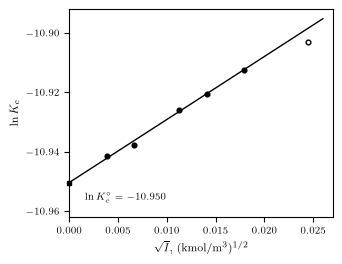

In [8]:
fig7, ax = plt.subplots(figsize=(3.4, 2.7))

x_line = np.array([0.0, 0.026])
ax.plot(x_line, inter_free + slope_free * x_line, "-", color="k", lw=1.0)

# The five points the line is fitted to, and the sixth, which is not. Filled against open
# is the only distinction, and it needs no legend because the caption carries it.
ax.plot(root_I[:5], ln_Kc[:5], "o", color="k", ms=3.4, mfc="k", zorder=3)
ax.plot(root_I[5:], ln_Kc[5:], "o", color="k", ms=3.4, mfc="w", zorder=3)

# The intercept is the answer, so it is marked rather than left to be read off the axis.
ax.plot([0.0], [inter_free], "s", color="k", ms=3.0, zorder=4, clip_on=False)
ax.annotate(rf"$\ln K_c^{{\circ}} = {inter_free:.3f}$",
            xy=(0.0, inter_free), xytext=(0.0016, inter_free - 0.0032),
            fontsize=7, va="top", ha="left")

ax.set_xlim(0.0, 0.027)
ax.set_xticks(np.arange(0.0, 0.0271, 0.005))
ax.set_xlabel(r"$\sqrt{I}$, $(\mathrm{kmol/m^3})^{1/2}$", fontsize=8)

ax.set_ylim(-10.962, -10.892)
ax.set_yticks(np.arange(-10.96, -10.893, 0.02))
ax.set_ylabel(r"$\ln K_c$", fontsize=8)
ax.tick_params(labelsize=7)

print(f"fitted line: ln Kc = {inter_free:.4f} + {slope_free:.3f} sqrt(I)")
print(f"intercept marked at {inter_free:.4f}, Ka = {np.exp(inter_free):.4e}")

## What the figure shows

Five statements, each asserted against the numbers rather than described, so that a change
in the data or in the constant cannot invalidate the text beside the art unnoticed.

In [9]:
checks = []
checks.append(("Kc rises monotonically with ionic strength",
               bool(np.all(np.diff(Kc) > 0))))
checks.append((f"the whole rise in Kc is only {100*(Kc[-1]/Kc[0]-1):.1f} percent, which is"
               f" why a constant looks constant",
               (Kc[-1] / Kc[0] - 1) < 0.05))
checks.append(("the five low-I points are straight in sqrt(I) to better than 0.002 in ln Kc",
               float(np.max(np.abs(ln_Kc[:5] - (inter_free + slope_free*root_I[:5]))))
               < 2e-3))
checks.append((f"the sixth point falls BELOW that line, by "
               f"{(inter_free + slope_free*root_I[5]) - ln_Kc[5]:.4f} in ln Kc -- the"
               f" limiting law is failing there, not the data",
               ln_Kc[5] < inter_free + slope_free * root_I[5]))
checks.append((f"all three extrapolation routes give dG within "
               f"{max(abs(dG_fixed-27.15), abs(dG_free-27.15)):.3f} kJ/mol of the printed"
               f" 27.15 -- the answer does not depend on how the line is drawn",
               abs(dG_fixed - 27.15) < 0.02 and abs(dG_free - 27.15) < 0.02))

for text, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {text}")
assert all(ok for _, ok in checks)

  PASS  Kc rises monotonically with ionic strength
  PASS  the whole rise in Kc is only 3.9 percent, which is why a constant looks constant
  PASS  the five low-I points are straight in sqrt(I) to better than 0.002 in ln Kc
  PASS  the sixth point falls BELOW that line, by 0.0047 in ln Kc -- the limiting law is failing there, not the data
  PASS  all three extrapolation routes give dG within 0.006 kJ/mol of the printed 27.15 -- the answer does not depend on how the line is drawn


## Staging the art

The figure is drawn at the size it is printed at -- 3.4 in wide, one column -- so that 7 pt
in the notebook is 7 pt on the page.

In [10]:
os.makedirs("pdf", exist_ok=True)
path = "pdf/Figure_13.1-7.pdf"
fig7.savefig(path, dpi=300, bbox_inches="tight")
print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")

  wrote pdf/Figure_13.1-7.pdf

  typography: LaTeX Computer Modern


## Your turn

1. The fitted slope is about 2.12 where Eq. 13.1-32 predicts 2.356, and the notebook
   deliberately stops there rather than explaining it. Settle it. Three candidates to
   test before anything else: that the ionic strength should be computed on a
   **molality** basis rather than a molarity one; that the extended form of the law -- the
   one printed after Fig. 13.5-1, with the $1+A\sqrt{I}$ denominator -- is what these data require even at $I<10^{-3}$; and that $\gamma$ for the *undissociated* acid, set to one
   throughout, is not one. Which of the three moves the slope in the right direction, and
   by how much? Report the fitted slope for each.
2. Refit the line using **all six** points instead of five, and report the intercept, the
   slope and $\Delta_{\rm rxn}G^{\circ}$. Then plot the residuals of both fits against
   $\sqrt{I}$. At what ionic strength would you say the limiting law stops being usable
   for these data, and what does the residual plot show that the fitted line does not?
3. Illustration 13.1-9 assumes $K_c$ is independent of concentration and says so.
   Illustration 13.1-10 measures $K_c$ varying by 4 % over a range of ionic strength a
   thousand times *smaller* than the esterification's concentrations. Is the assumption in
   13.1-9 therefore wrong? Argue it from the source of the two effects -- what makes
   $K_{\gamma}$ move in an ionic solution, and what makes it move in a concentrated
   nonelectrolyte one -- rather than from the size of the numbers.
4. The esterification stops near 57 % conversion, and the notebook shows that removing
   water would push it much further. Suppose instead you double the ethanol. Compute the
   new conversion of the acid, and the new conversion of the *ethanol*. Which reactant
   should be in excess if the ester is the product you are selling, and why is that not the
   same question as which conversion is higher?
5. Recover $K_a$ from the formation properties instead of from the data. Appendix A.IV
   tabulates $\Delta_fG^{\circ}$ for CH$_3$COOH(aq), CH$_3$COO$^-$(aq) and H$^+$(aq) at the
   ideal 1-molal standard state. Compute $\Delta_{\rm rxn}G^{\circ}$ and $K_a$ that way and
   compare with the 27.15 kJ/mol here. Which of the two routes would you trust to three
   figures, and what does the answer say about the sentence in Sec. 13.1 that recommends
   using measured $K_c$ data "if such data are available"?
6. The conductance measurement gives the acetate concentration; the mass balance gives the
   undissociated acid as $C_T-C_{\rm Ac^-}$. Propagate a 1 % error in the measured acetate
   concentration through to $K_c$ at the most dilute point and at the most concentrated
   one. Why is the most dilute point -- the one nearest the intercept you want -- the worst
   conditioned of the six, and what does that imply about how such an experiment should be
   designed?